In [40]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
from scipy.stats import norm
from sympy.tensor import tensor
%matplotlib inline

In [41]:
# read in all the lines
words = open('names.txt', 'r').read().splitlines()
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi  = {s: i + 1 for i, s in enumerate(chars)}
stoi['.'] = 0
itos  = {i: s for s, i in stoi.items()}
vocab_size = 27
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [42]:
import random
block_size = 3
vocab_size = len(itos)
def build_dataset(words):
    X, Y = [], []
    for w in words:
        context = [0] * block_size
        for ch in w + '.':
            ix = stoi[ch]
            X.append(context)
            Y.append(ix)
            context = context[1:] + [ix]

    X = torch.tensor(X)
    Y = torch.tensor(Y)
    print(X.shape, Y.shape)
    return X, Y

random.seed(42)
random.shuffle(words)
n1 = int(0.8 * len(words))
n2 = int(0.9 * len(words))

Xtr,  Ytr  = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte,  Yte  = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [43]:
n_embd = 10
n_hidd = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator = g)
W1 = torch.randn((block_size * n_embd, n_hidd), generator = g)  * ((5 / 3) / ((block_size * n_embd) ** 0.5))# 0.2
b1 = torch.randn(n_hidd,                        generator = g) * 0.01
W2 = torch.randn((n_hidd, vocab_size),          generator = g) * 0.01
b2 = torch.randn(vocab_size,                    generator = g) * 0

# bngain         = torch.ones((1, n_hidd))
# bnbias         = torch.zeros((1, n_hidd))
# bnstd_running  = torch.ones((1, n_hidd))
# bnmean_running = torch.zeros((1, n_hidd))

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


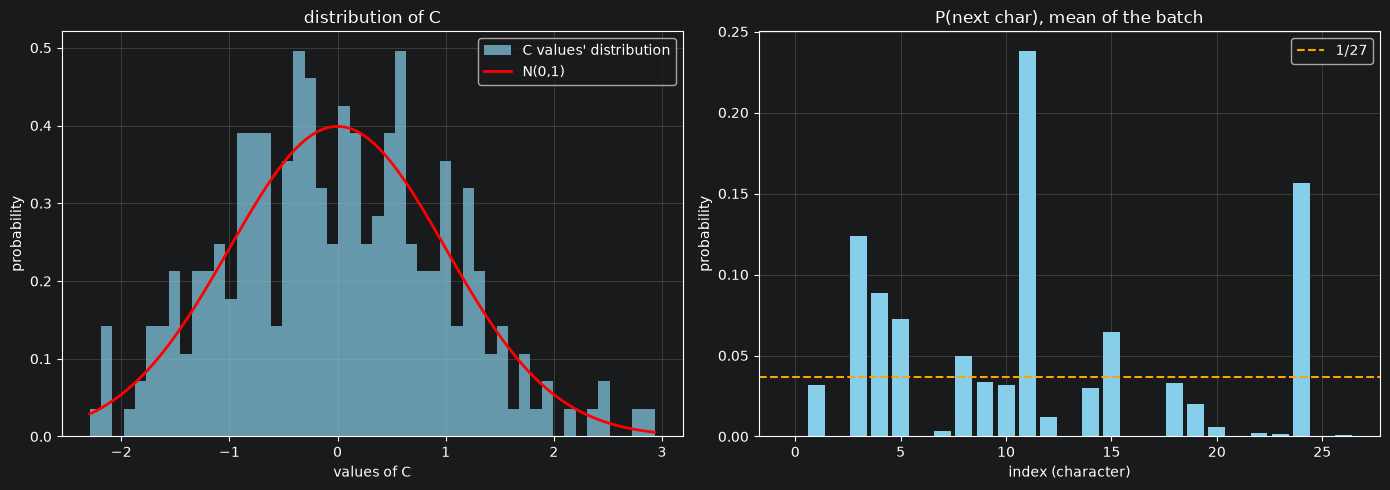

In [44]:
# and this example was trained for only 1 time to draw the graph of incorrect initialization.
# if it's too bad looking, i'll draw more.
g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidd), generator=g)
b1 = torch.randn(n_hidd, generator=g)
W2 = torch.randn((n_hidd, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2
probs = F.softmax(logits, dim=1)

hp_flat = C.detach().flatten()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(hp_flat, bins=50, density=True, alpha=0.7, color='skyblue', label="C values' distribution")
x = torch.linspace(float(hp_flat.min()), float(hp_flat.max()), 100)
y = torch.exp(-0.5 * x**2) / (2 * torch.pi)**0.5
axes[0].plot(x, y, 'r-', lw=2, label='N(0,1)')
# axes[0].axvline(1/27, color='orange', linestyle='--', linewidth=1.5, label='1/27 ≈ 0.037')
axes[0].set_xlabel('values of C')
axes[0].set_ylabel('probability')
axes[0].set_title('distribution of C')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].bar(range(vocab_size), probs.mean(dim=0).detach().numpy(), color='skyblue')
axes[1].axhline(1/27, color='orange', linestyle='--', linewidth=1.5, label='1/27')
axes[1].set_xlabel('index (character)')
axes[1].set_ylabel('probability')
axes[1].set_title('P(next char), mean of the batch')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

11897


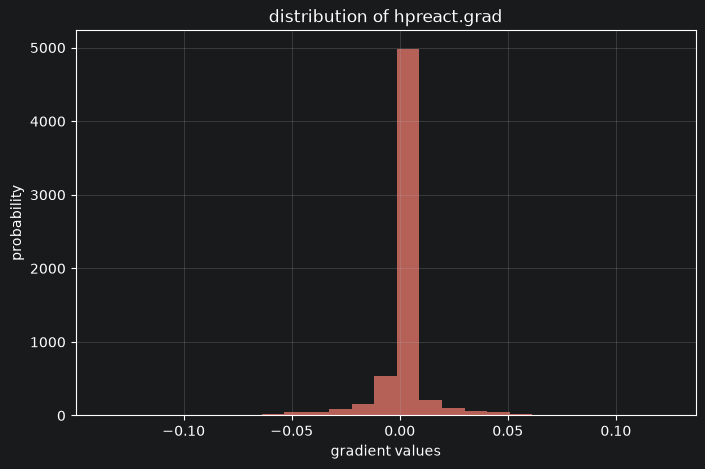

In [45]:
# and this example was trained for only 1 time to draw the graph of incorrect initialization.
# if it's too bad looking, i'll draw more.
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidd), generator=g)
b1 = torch.randn(n_hidd, generator=g)
W2 = torch.randn((n_hidd, vocab_size), generator=g)
b2 = torch.randn(vocab_size, generator=g)

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2

loss    = F.cross_entropy(logits, Yb)
# backward pass
for p in parameters:
    p.grad = None
for t in [hpreact]:
    t.retain_grad()
loss.backward()

grad_flat = hpreact.grad.detach().flatten()
plt.figure(figsize=(8, 5))
plt.hist(grad_flat, bins=25, alpha=0.7, color='salmon')
plt.xlabel('gradient values')
plt.ylabel('probability')
plt.title('distribution of hpreact.grad')
plt.grid(alpha=0.3)
plt.show()

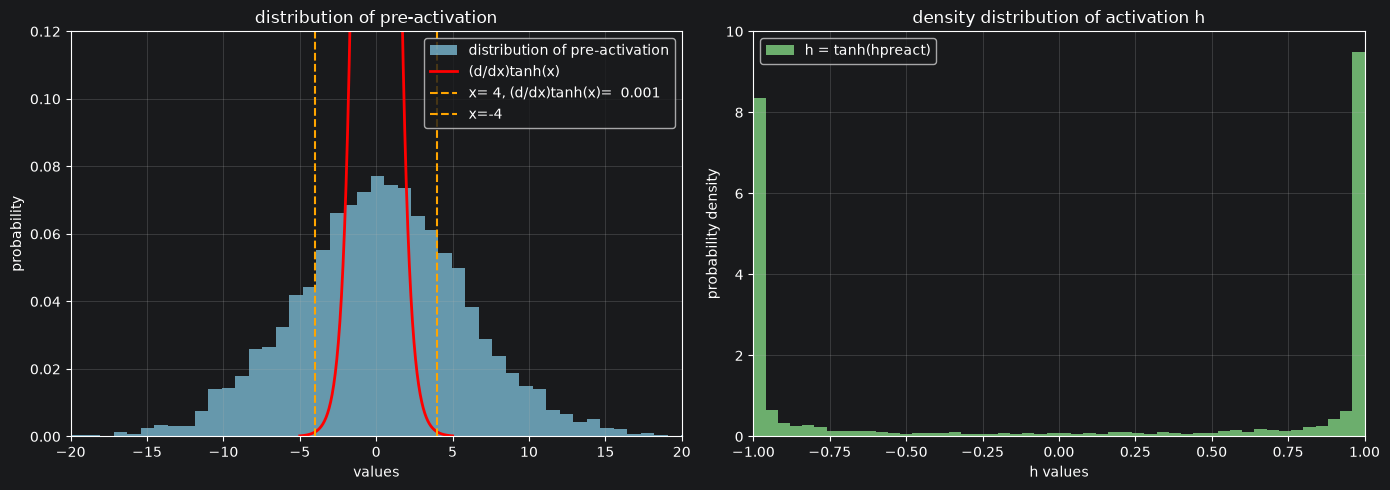

In [46]:
#
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ---preact
hp_flat = hpreact.detach().flatten()
axes[0].hist(hp_flat, bins=50, density=True, alpha=0.7, color='skyblue', label='distribution of pre-activation')
x = torch.linspace(float(-5.0), float(5.0), 100)
y = torch.cosh(x)**-2
axes[0].plot(x, y, 'r-', lw=2, label='(d/dx)tanh(x)')
axes[0].axvline(4, color='orange', linestyle='--', linewidth=1.5,
                label=f'x= 4, (d/dx)tanh(x)= {(torch.cosh(torch.tensor(4))**-2).item(): .3f}')
axes[0].axvline(-4, color='orange', linestyle='--', linewidth=1.5, label='x=-4')
axes[0].set_xlabel('values')
axes[0].set_ylabel('probability')
axes[0].set_title('distribution of pre-activation')
axes[0].set_xlim(-20, 20)
axes[0].set_ylim(0, 0.12)
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---
h_flat = h.view(-1).tolist()
axes[1].hist(h_flat, bins=50, density=True, alpha=0.7, color='lightgreen', label='h = tanh(hpreact)')
axes[1].set_xlabel('h values')
axes[1].set_ylabel('probability density')
axes[1].set_title('density distribution of activation h')
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(0, 10)
axes[1].legend()
axes[1].grid(alpha=0.3)

# ---
# grad_flat = hpreact.grad.detach().flatten()
# axes[2].hist(grad_flat, bins=25, density=True, alpha=0.7, color='salmon', label='distribution of hpreact.grad')
# axes[2].set_xlabel('gradient values')
# axes[2].set_ylabel('probability density')
# axes[2].set_title('distribution of hpreact.grad')
# axes[2].legend()
# axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [47]:
n_embd = 10
n_hidd = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator = g)
W1 = torch.randn((block_size * n_embd, n_hidd), generator = g) * ((5 / 3) / ((block_size * n_embd) ** 0.5))# 0.2
b1 = torch.randn(n_hidd,                        generator = g) * 0.01
W2 = torch.randn((n_hidd, vocab_size),          generator = g) * 0.01
b2 = torch.randn(vocab_size,                    generator = g) * 0

# bngain         = torch.ones((1, n_hidd))
# bnbias         = torch.zeros((1, n_hidd))
# bnstd_running  = torch.ones((1, n_hidd))
# bnmean_running = torch.zeros((1, n_hidd))

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


11897


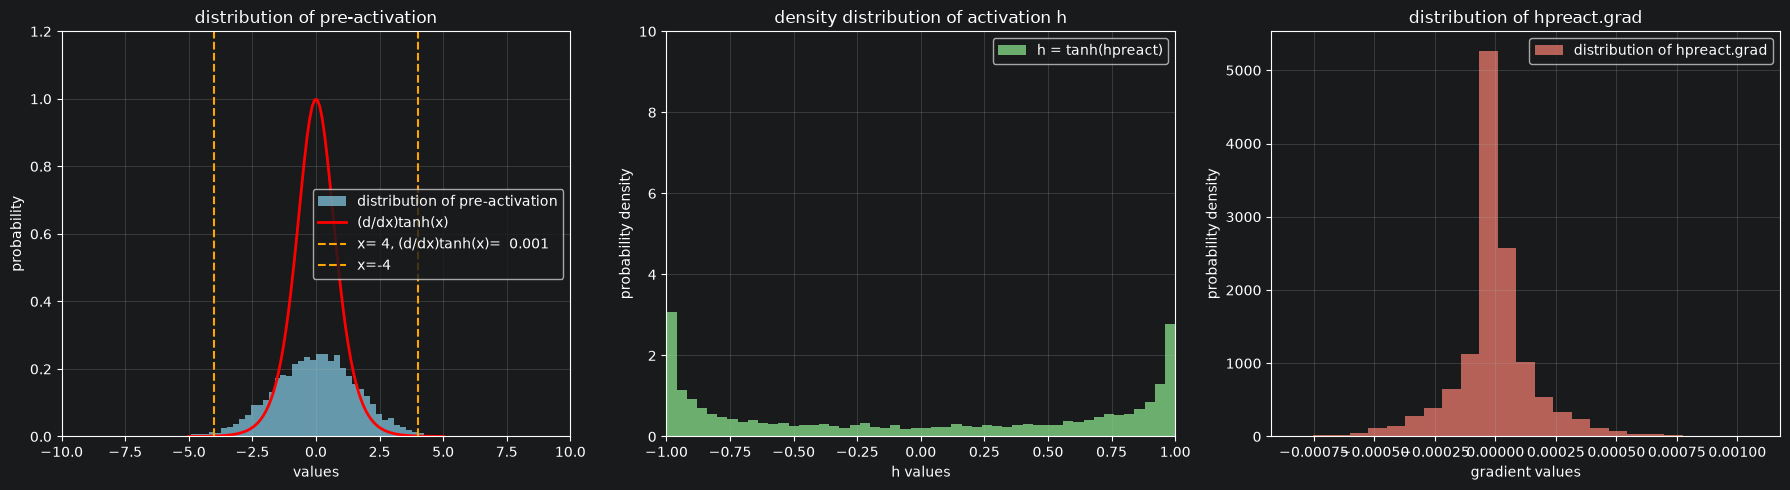

In [48]:
# after kaiming init
C = torch.randn((vocab_size, n_embd), generator=g)
W1 = torch.randn((block_size * n_embd, n_hidd), generator=g) * ((5 / 3) / ((block_size * n_embd) ** 0.5))# 0.2
b1 = torch.randn(n_hidd, generator=g) * 0.01
W2 = torch.randn((n_hidd, vocab_size), generator=g) * 0.01
b2 = torch.randn(vocab_size, generator=g) * 0

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

ix = torch.randint(0, Xtr.shape[0], (32,), generator=g)
Xb, Yb = Xtr[ix], Ytr[ix]
emb = C[Xb]
embcat = emb.view(emb.shape[0], -1)
hpreact = embcat @ W1 + b1
h = torch.tanh(hpreact)
logits = h @ W2 + b2

loss    = F.cross_entropy(logits, Yb)
# backward pass
for p in parameters:
    p.grad = None
for t in [hpreact]:
    t.retain_grad()
loss.backward()

# ---
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# ---preact
hp_flat = hpreact.detach().flatten()
axes[0].hist(hp_flat, bins=50, density=True, alpha=0.7, color='skyblue', label='distribution of pre-activation')
x = torch.linspace(float(-5.0), float(5.0), 100)
y = torch.cosh(x)**-2
axes[0].plot(x, y, 'r-', lw=2, label='(d/dx)tanh(x)')
axes[0].axvline(4, color='orange', linestyle='--', linewidth=1.5,
                label=f'x= 4, (d/dx)tanh(x)= {(torch.cosh(torch.tensor(4))**-2).item(): .3f}')
axes[0].axvline(-4, color='orange', linestyle='--', linewidth=1.5, label='x=-4')
axes[0].set_xlabel('values')
axes[0].set_ylabel('probability')
axes[0].set_title('distribution of pre-activation')
axes[0].set_xlim(-10, 10)
axes[0].set_ylim(0, 1.2)
axes[0].legend()
axes[0].grid(alpha=0.3)

# ---
h_flat = h.view(-1).tolist()
axes[1].hist(h_flat, bins=50, density=True, alpha=0.7, color='lightgreen', label='h = tanh(hpreact)')
axes[1].set_xlabel('h values')
axes[1].set_ylabel('probability density')
axes[1].set_title('density distribution of activation h')
axes[1].set_xlim(-1, 1)
axes[1].set_ylim(0, 10)
axes[1].legend()
axes[1].grid(alpha=0.3)

# ---
grad_flat = hpreact.grad.detach().flatten()
axes[2].hist(grad_flat, bins=25, density=True, alpha=0.7, color='salmon', label='distribution of hpreact.grad')
axes[2].set_xlabel('gradient values')
axes[2].set_ylabel('probability density')
axes[2].set_title('distribution of hpreact.grad')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [49]:
n_embd = 10
n_hidd = 200

g = torch.Generator().manual_seed(2147483647)
C = torch.randn((vocab_size, n_embd),           generator = g)
W1 = torch.randn((block_size * n_embd, n_hidd), generator = g)  * ((5 / 3) / ((block_size * n_embd) ** 0.5))# 0.2
b1 = torch.randn(n_hidd,                        generator = g) * 0.01
W2 = torch.randn((n_hidd, vocab_size),          generator = g) * 0.01
b2 = torch.randn(vocab_size,                    generator = g) * 0

bngain         = torch.ones((1, n_hidd))
bnbias         = torch.zeros((1, n_hidd))
bnstd_running  = torch.ones((1, n_hidd))
bnmean_running = torch.zeros((1, n_hidd))

parameters = [C, W1, b1, W2, b2]
print(sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

11897


In [50]:
max_steps   = 200000
batch_size  = 32
lossi       = []

for i in range(200000):
    # minibatch construct
    ix      = torch.randint(0, Xtr.shape[0], (batch_size, ), generator = g)
    Xb, Yb  = Xtr[ix], Ytr[ix]

    # forward pass
    emb     = C[Xb]
    embcat  = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 + b1

    bnmeani = hpreact.mean(0, keepdim=True)
    bnstdi  = hpreact.std(0, keepdim=True)
    hpreact = bngain * (hpreact - bnmeani) / bnstdi - bnbias

    with torch.no_grad():
        bnmean_running = 0.999 * bnmean_running + 0.001 * bnmeani
        bnstd_running  = 0.999 * bnstd_running  + 0.001 * bnstdi

    h       = torch.tanh(hpreact)
    logits  = h @ W2 + b2
    loss    = F.cross_entropy(logits, Yb)

    # backward pass
    for p in parameters:
        p.grad = None

    for t in [hpreact]:
        t.retain_grad()
    loss.backward()

    # update

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"{i: 7d}/{max_steps: 7d}, loss: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    # if i == 30000:
    #     break


print("loss:", loss.item())

      0/ 200000, loss: 3.3147
  10000/ 200000, loss: 2.1942
  20000/ 200000, loss: 2.3443
  30000/ 200000, loss: 2.4160
  40000/ 200000, loss: 1.9913
  50000/ 200000, loss: 2.2978
  60000/ 200000, loss: 2.5254
  70000/ 200000, loss: 2.0707
  80000/ 200000, loss: 2.3107
  90000/ 200000, loss: 2.0663
 100000/ 200000, loss: 1.9933
 110000/ 200000, loss: 2.3179
 120000/ 200000, loss: 1.9123
 130000/ 200000, loss: 2.4505
 140000/ 200000, loss: 2.4321
 150000/ 200000, loss: 2.2003
 160000/ 200000, loss: 2.0463
 170000/ 200000, loss: 1.8839
 180000/ 200000, loss: 1.9983
 190000/ 200000, loss: 1.8873
loss: 2.411559581756592


In [51]:
with torch.no_grad():
    emb = C[Xtr]
    embcat = emb.view(emb.shape[0], -1)
    hpreact = embcat @ W1 # + b1
    # measure the mean/std over the entire training set
    bnmean = hpreact.mean(0, keepdim=True)
    bnstd = hpreact.std(0, keepdim=True)

In [54]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean_running) / bnstd_running + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.078160524368286
val 2.113025665283203
test 2.113367795944214


In [55]:
@torch.no_grad() # this decorator disables gradient tracking
def split_loss(split):
  x,y = {
    'train': (Xtr, Ytr),
    'val': (Xdev, Ydev),
    'test': (Xte, Yte),
  }[split]
  emb = C[x] # (N, block_size, n_embd)
  embcat = emb.view(emb.shape[0], -1) # concat into (N, block_size * n_embd)
  hpreact = embcat @ W1 # + b1
  #hpreact = bngain * (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True) + bnbias
  hpreact = bngain * (hpreact - bnmean) / bnstd + bnbias
  h = torch.tanh(hpreact) # (N, n_hidden)
  logits = h @ W2 + b2 # (N, vocab_size)
  loss = F.cross_entropy(logits, y)
  print(split, loss.item())

split_loss('train')
split_loss('val')
split_loss('test')

train 2.0785984992980957
val 2.112916946411133
test 2.1131272315979004


And here is viz in the video.

In [56]:
# Let's train a deeper network.
class Linear:
    def __init__(self, fan_in, fan_out, bias = True):
        g           = torch.Generator().manual_seed(2147483647)
        # Kaiming initialization
        self.weight = torch.randn((fan_in, fan_out), generator = g) / fan_in ** 0.5
        self.bias   = torch.zeros(fan_out) if bias else None

    def __call__(self, x):
        self.out = x @ self.weight
        if self.bias is not None:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

class BatchNorm1d:
    """affine will be true which means using gamma and beta during training.
    track_running_stats will be true, keep tracking running mean and variance.
    device by default is cpu(but i hope is gpu.).
    datatype float32.
    """
    def __init__(self, dim, eps = 1e-5, momentum = 0.1):
        self.eps      = eps
        self.momentum = momentum
        self.training = True

        # parameters (trained with backprop.)
        self.gamma = torch.ones(dim)
        self.beta  = torch.zeros(dim)

        # buffers (trained with a running momentum update)
        self.running_mean = torch.zeros(dim)
        self.running_var  = torch.ones(dim)

    def __call__(self, x):
        # calculate the forward pass.
        if self.training:
            xmean = x.mean(0, keepdim = True) # batch mean
            xvar  = x.var(0, keepdim = True)  # batch variance
        else:
            xmean = self.running_mean
            xvar  = self.running_var
        xhat = (x - xmean) / torch.sqrt(xvar + self.eps) # normalized to unit variance
        self.out = self.gamma * xhat + self.beta
        if self.training:
            with torch.no_grad():
                self.running_mean = (1 - self.momentum) * self.running_mean + self.momentum * xmean
                self.running_var  = (1 - self.momentum) * self.running_var + self.momentum * xvar
        return self.out

    def parameters(self):
        return [self.gamma, self.beta]

class Tanh:
    def __call__(self, x):
        self.out = torch.tanh(x)
        return self.out
    def parameters(self):
        return []

In [63]:
import torch
n_embd = 10
n_hidd = 100
vocab_size = 27
g      = torch.Generator().manual_seed(2147483647)
gain = 5 / 3

C = torch.randn((vocab_size, n_embd), generator = g)
# layers = [
#     Linear(n_embd * block_size, n_hidd), BatchNorm1d(n_hidd), Tanh(),
#     Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
#     Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
#     Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
#     Linear(             n_hidd, n_hidd), BatchNorm1d(n_hidd), Tanh(),
#     Linear(         n_hidd, vocab_size), BatchNorm1d(vocab_size),
# ]

layers = [
    Linear(n_embd * block_size, n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), Tanh(),
    Linear(             n_hidd, n_hidd), Tanh(),
    Linear(         n_hidd, vocab_size),
]

with torch.no_grad():
    # last layer, make less output softmax confident
    # layers[-1].gamma *= 0.1 # for batchnorm
    layers[-1].weight *= 0.1 # no batchnorm
    # all other layers apply gain.
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= gain

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print("param_num: ", sum(p.nelement() for p in parameters))
for p in parameters:
    p.requires_grad = True

param_num:  46497


In [64]:
max_steps   = 200000
batch_size  = 32
lossi       = []
ud          = []

for i in range(200000):

    # minibatch construct
    ix      = torch.randint(0, Xtr.shape[0], (batch_size, ))
    Xb, Yb  = Xtr[ix], Ytr[ix] # Batch X and Y.

    # forward pass
    emb = C[Xb] # embed the characters into vectors
    x   = emb.view(emb.shape[0], -1) # concatenate the vectors
    for layer in layers:
        x = layer(x)
    loss = F.cross_entropy(x, Yb)

    # backward pass
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
    loss.backward()

    # update

    lr = 0.1 if i < 100000 else 0.01
    for p in parameters:
        p.data += -lr * p.grad

    # track stats
    if i % 10000 == 0:
        print(f"{i: 7d}/{max_steps: 7d}, loss: {loss.item():.4f}")
    lossi.append(loss.log10().item())
    with torch.no_grad():
        ud.append([((lr*p.grad).std() / p.data.std()).log10().item() for p in parameters])

    if i == 1000:
        break

print("loss:", loss.item())

      0/ 200000, loss: 3.2821
loss: 2.076775074005127


layer 1 (      Tanh): mean +0.02, std 0.76, saturated 20.03%
layer 3 (      Tanh): mean +0.00, std 0.71, saturated 10.97%
layer 5 (      Tanh): mean +0.05, std 0.72, saturated 12.28%
layer 7 (      Tanh): mean +0.05, std 0.74, saturated 13.56%
layer 9 (      Tanh): mean -0.03, std 0.72, saturated 10.84%


Text(0.5, 1.0, 'gain=1.6666666666666667,activation distribution')

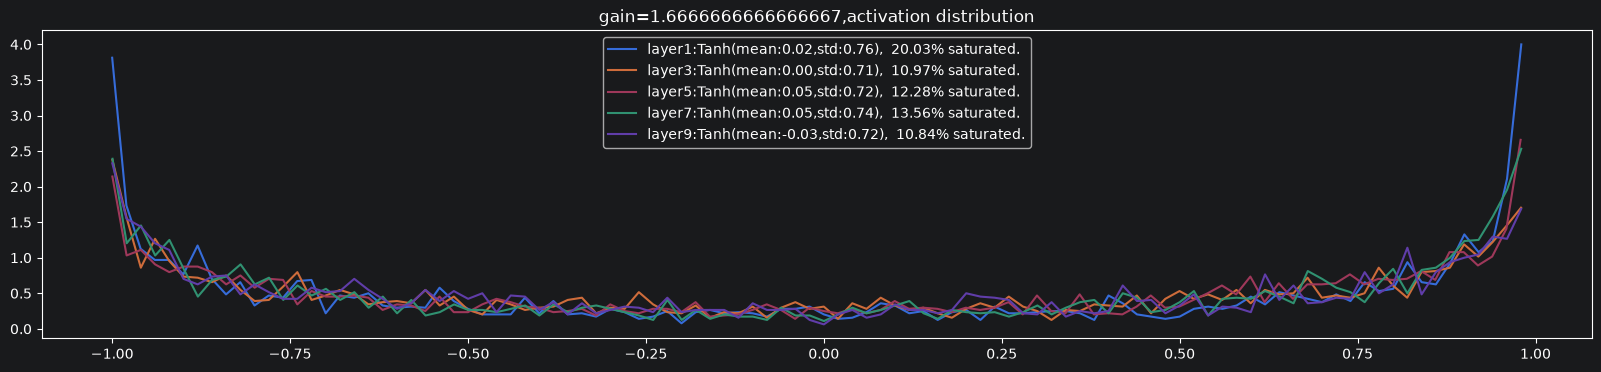

In [65]:
# visualize histograms
plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out
        print('layer %d (%10s): mean %+.2f, std %.2f, saturated %.2f%%' % (i, layer.__class__.__name__, t.mean().item(), t.std().item(), (t.abs() > 0.97).float().mean().item() * 100))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer{i}:{layer.__class__.__name__}(mean:{t.mean().item():.2f},std:{t.std().item():.2f}), {(t.abs() > 0.97).float().mean().item() * 100: .2f}% saturated.')
plt.legend(legends)
plt.title(f'gain={gain},activation distribution')

layer 1 (      Tanh): mean -0.000045, std 3.064048e-03
layer 3 (      Tanh): mean -0.000067, std 2.838667e-03
layer 5 (      Tanh): mean +0.000030, std 2.711270e-03
layer 7 (      Tanh): mean -0.000006, std 2.727840e-03
layer 9 (      Tanh): mean -0.000003, std 2.272943e-03


Text(0.5, 1.0, 'gain=1.6666666666666667,gradient distribution')

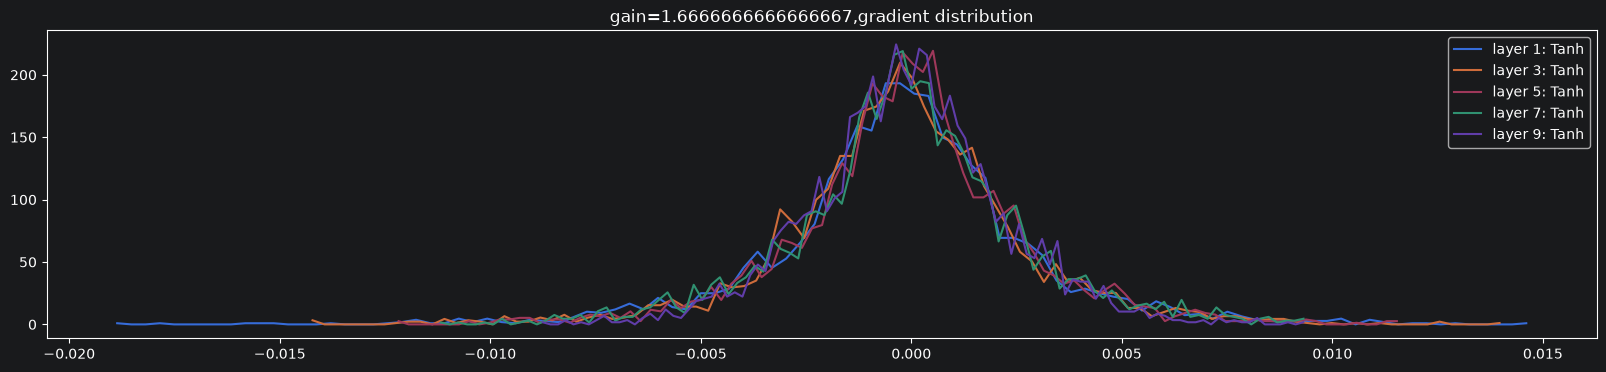

In [66]:
# visualize histograms
plt.figure(figsize = (20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        print('layer %d (%10s): mean %+f, std %e' % (i, layer.__class__.__name__, t.mean().item(), t.std().item()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'layer {i}: {layer.__class__.__name__}')
plt.legend(legends)
plt.title(f'gain={gain},gradient distribution')

weight   (27, 10)| mean -0.001122| std 9.780765e-03| grad:data ratio 9.775695e-03
weight  (30, 100)| mean -0.000044| std 9.032123e-03| grad:data ratio 2.924343e-02
weight (100, 100)| mean +0.000019| std 7.175177e-03| grad:data ratio 4.230824e-02
weight (100, 100)| mean +0.000051| std 5.908816e-03| grad:data ratio 3.491286e-02
weight (100, 100)| mean +0.000084| std 5.446527e-03| grad:data ratio 3.218813e-02
weight (100, 100)| mean +0.000051| std 5.006735e-03| grad:data ratio 2.968833e-02
weight  (100, 27)| mean -0.000000| std 2.157505e-02| grad:data ratio 3.139025e-01


Text(0.5, 1.0, 'weights gradient distribution')

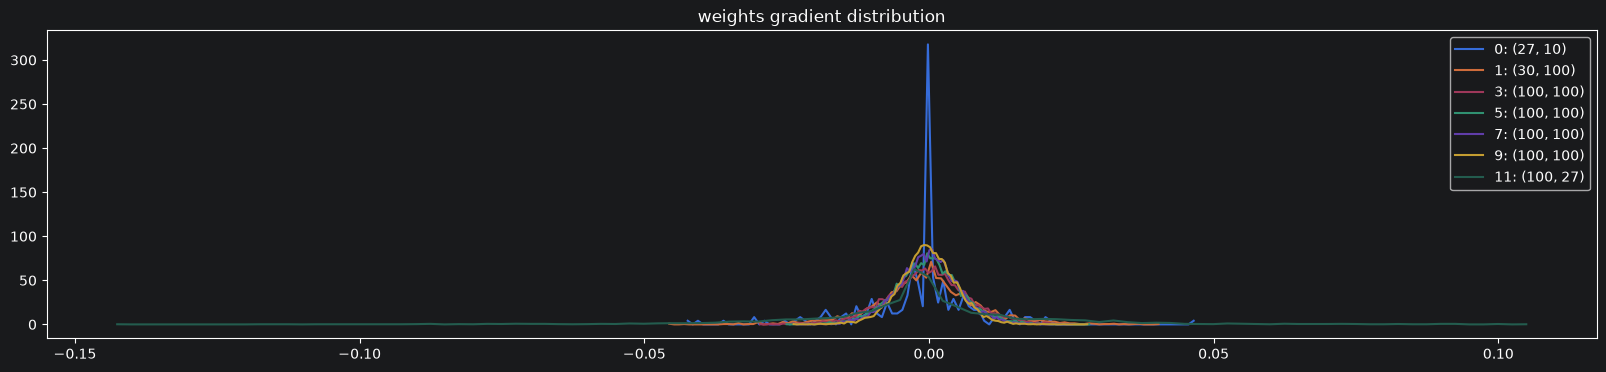

In [67]:
# visualize histograms
plt.figure(figsize = (20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if p.ndim == 2:
        print('weight %10s| mean %+f| std %e| grad:data ratio %e' % (tuple(p.shape), t.mean().item(), t.std().item(), t.std().item() / p.std().item()))
        hy, hx = torch.histogram(t, density = True)
        plt.plot(hx[:-1].detach(), hy.detach())
        legends.append(f'{i}: {tuple(p.shape)}')
plt.legend(legends)
plt.title('weights gradient distribution')

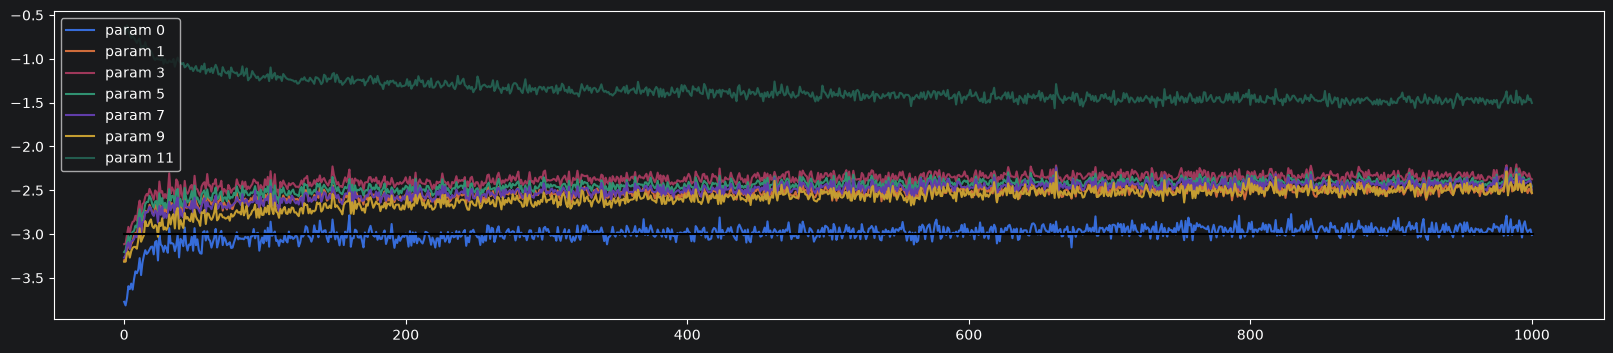

In [68]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
  if p.ndim == 2:
    plt.plot([ud[j][i] for j in range(len(ud))])
    legends.append('param %d' % i)
plt.plot([0, len(ud)], [-3, -3], 'k') # these ratios should be ~1e-3, indicate on plot
plt.legend(legends);